<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/Inverse_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
from google.colab import drive
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

In [ ]:
seed_val = 42
set_seed(seed_val)

In [ ]:
!unzip "/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/Saved_variables/05-09-2024_all_images-20240509T194653Z-001.zip"
!unzip "/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/New Image Generation/Generated Images-20240523T233205Z-001.zip"
!unzip "/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/New Image Generation/Generated_Images_7-2-24-20240702T205017Z-001.zip"
# !unzip "/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/New Image Generation/ImageJ_Data.zip"
# !unzip "/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/Inverted_colors_ImageJ_Data.zip"


In [ ]:
# @title

# #load in dataframe
# pd.set_option('display.max_columns', None)

# with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_df.pkl", 'rb') as f:
#   feats_df = pickle.load(f) # deserialize using load()

# feats_df = feats_df[feats_df.columns[0:63]]


# print(feats_df.shape)
# feats_df.head()


In [ ]:
# @title
# ij_feats_files = os.listdir("/content/Inverted_colors_ImageJ_Data")
# # feats_df.head()
# len(ij_feats_files)

39517

In [ ]:
# @title
# print(ij_feats_files[0])

noise 3 21225.0.png.csv


In [ ]:
# @title
# ij_feats = []
# counter = 0

# for i in range(feats_df.shape[0]):
#   a = (pd.read_csv("/content/Inverted_colors_ImageJ_Data/" + feats_df["path"][i] + ".csv"))
#   ij_feats.append(a)
#   if counter % 500 == 0:
#     print(counter)
#   counter += 1




In [ ]:
# @title
# feats_df[""] = ij_feats

# feats_df = feats_df[feats_df["feat_bool"] == 1]
# feats_df.reset_index(inplace = True, drop = True)

In [ ]:
# @title
# counter = 0
# ij_feat_dfs = []
# for i in range(feats_df.shape[0]):

#   ij_feat_dfs.append(pd.read_csv("/content/Inverted_colors_ImageJ_Data/" + feats_df["path"][i] + ".csv"))

#   if counter % 1000 == 0:
#     print(counter)
#   counter += 1

# feats_df["ij_feats_inverted"] = ij_feats




In [ ]:
# @title
# dir_1 = os.listdir("/content/05-09-2024_all_images/")
# dir_2 = os.listdir("/content/Generated Images/")
# dir_3 = os.listdir("/content/Generated_Images_7-2-24/")

In [ ]:
# @title
# #add directorys to the feats_df:

# #load in dataframe
# pd.set_option('display.max_columns', None)

# with open("/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/Saved_variables/2024-07-08_img_df.pkl", 'rb') as f:
#   feats_df = pickle.load(f) # deserialize using load()

# feats_df.shape

# # dir_1_name = "/content/05-09-2024_all_images/"
# # dir_2_name = "/content/Generated Images/"
# # dir_3_name = "/content/Generated_Images_7-2-24/"

# # dirs = [dir_1_name] * len(dir_1) + [dir_2_name] * len(dir_2) + [dir_3_name]*len(dir_3)

# # feats_df["dir"] = dirs

# # pickle_out = open("/content/drive/Shareddrives/Summer_2023_VCell_Ml/2024-05-09 New Work/Saved_variables/2024-07-08_img_df.pkl","wb")
# # pickle.dump(feats_df, pickle_out)
# # pickle_out.close()


(39917, 12)

In [ ]:
# @title
# ij_feats_files = os.listdir("/content/Inverted_colors_ImageJ_Data/")
# # ij_feats_files = os.listdir("/content/Data/")
# # feats_df.head()

In [ ]:
# @title

# #load in dataframe
# pd.set_option('display.max_columns', None)

# with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_df.pkl", 'rb') as f:
#   feats_df = pickle.load(f) # deserialize using load()

# feats_df.shape

(39517, 113)

In [ ]:

#load in dataframe
pd.set_option('display.max_columns', None)

with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

feats_df.shape

(39517, 111)

In [ ]:
# @title
# # make a feats_df that is easier to load and work with by removing feats df columns

# feats_df = feats_df.drop('ij_feats', axis = "columns")
# feats_df = feats_df.drop('ij_feats_inverted', axis = "columns")

In [ ]:
# @title
# #save easier to worl with df

# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_no_dfs_df.pkl","wb")
# pickle.dump(feats_df, pickle_out)
# pickle_out.close()


In [ ]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std
0,0.011652,0.1066,0.115805,0.061599,-0.043244,0.007928,0.559698,0,2,0.png,0,/content/05-09-2024_all_images/,1,1,255.000,255,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,797.657000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.790000,0.000000,282.843000,0.000000,1.020000e+07,0.000000,100.0,0.0,1.020000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,135.00000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0,0.000,0,40000.0,0.0,100.000,0.0,100.000,0.0,800.000,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,1.000,0.0
1,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3.136500e+03,649.910626,100.0,0.0,3.136500e+03,649.910626,97.942857,58.572760,96.014286,58.843981,120.12900,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0
2,0.014455,0.085124,0.091124,0.113974,-0.060333,0.001776,1.798215,0,2,2.png,2,/content/05-09-2024_all_images/,1,1,255.000,255,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,797.657000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.790000,0.000000,282.843000,0.000000,1.020000e+07,0.000000,100.0,0.0,1.020000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,135.00000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0,0.000,0,40000.0,0.0,100.000,0.0,100.000,0.0,800.000,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,1.000,0.0
3,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.8

In [ ]:
np.unique(feats_df["dir"])

array(['/content/05-09-2024_all_images/', '/content/Generated Images/',
       '/content/Generated_Images_7-2-24/'], dtype=object)

In [ ]:
# find ranges for confined scan
param_df = feats_df[feats_df["dir"] != '/content/05-09-2024_all_images/']

param_df.shape

# param_df.columns()

(24383, 111)

In [ ]:
type(feats_df["Ua"][0])

float

In [ ]:
for i in range(7):
  param = param_df.columns[i]
  param_list = param_df[param]
  min_param = np.min(param_list)
  max_param = np.max(param_list)
  print("Min " + param + " : " + str(np.min(param_list)))
  print("Max " + param + " : " + str(np.max(param_list)))

  feats_df = feats_df[feats_df[param].astype(float) >= float(min_param)]
  feats_df = feats_df[feats_df[param].astype(float) <=float(max_param)]

Min Ua : 0.008331157146038
Max Ua : 0.05168062913751636
Min Ui : 0.01005534267788842
Max Ui : 0.20997331184797063
Min Ga : 0.025109627789017666
Max Ga : 0.17498658244776577
Min Gi : 0.022726124962461736
Max Gi : 0.17727116615370253
Min Ba : -0.20192576230242676
Max Ba : -0.038046387668075596
Min Da : 0.008000164168755663
Max Da : 0.011997642199320636
Min Di : 0.2531168343748258
Max Di : 1.4972024448397565


In [ ]:
for i in range(7):
  param = feats_df.columns[i]
  param_list = feats_df[param].astype(float)
  # min_param = np.min(param_list)
  # max_param = np.max(param_list)
  print("Min " + param + " : " + str(np.min(param_list)))
  print("Max " + param + " : " + str(np.max(param_list)))

  feats_df.reset_index(inplace = True, drop = True)

feats_df.shape

Min Ua : 0.008331157146038
Max Ua : 0.05168062913751636
Min Ui : 0.01005534267788842
Max Ui : 0.20997331184797063
Min Ga : 0.025109627789017666
Max Ga : 0.17498658244776577
Min Gi : 0.022726124962461736
Max Gi : 0.17727116615370253
Min Ba : -0.20192576230242676
Max Ba : -0.038046387668075596
Min Da : 0.008000164168755663
Max Da : 0.011997642199320636
Min Di : 0.2531168343748258
Max Di : 1.4972024448397565


(33770, 111)

In [ ]:
# save feats_df with narrow parameters

# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-19_feats_df_narrow.pkl","wb")
# pickle.dump(feats_df, pickle_out)
# pickle_out.close()

In [ ]:
# @title
# # # extracting features
# # # first row is overall measurement
# # #each subsequent row is spots

# # # features = {
# # #         "area_mean" = [], "area_std" = [], "x_mean" = [], "x_std" = [],
# # #         "y_mean" = []. "y_std" = [], "perim_mean" = [], "perim_std" = [], # x,y are centroid, Bx, By are bounding rectangle
# # #         "bx_mean" = [], "bx_std" = [], "by_mean" = [], "by_std" = [] ,
# # #         "width_mean" = []. "width_std" = [], "height_mean" = [], "height_std" = [],
# # #         "circ_mean" = [], "circ_std" = [], "feret_mean" = [], "feret_std" = [],
# # #         "total_coverage" = [] # % area from first column
# # #         "feret_x_mean" = [], "feret_x_std" = [], "feret_y_mean" = [], "feret_y_std" = [],
# # #         "feret_angle_mean" = [], "feret_angle_std" = [], "min_feret_mean" = [], "min_feret_std" = [],
# # #         "ar_mean" = [], "ar_std" = [], "round_mean" = [], "round_std" = [], "solidity_mean" = [], "solidity_std" = []
# # #     }

# # # first list is mean, second list is std except for mean and median
# # # feats = {'Mean':[],'Median':[],'Area':[[],[]], 'X':[[],[]], 'Y':[[],[]], 'Perim.':[[],[]], 'BX':[[],[]],
# # #          'BY':[[],[]], 'Width':[[],[]], 'Height':[[],[]], 'Major':[[],[]], 'Minor':[[],[]],
# # #        'Angle':[[],[]], 'Circ.':[[],[]], 'Feret':[[],[]], 'IntDen':[[],[]], '%Area':[[],[]],
# # #        'RawIntDen':[[],[]], 'FeretX':[[],[]], 'FeretY':[[],[]], 'FeretAngle':[[],[]], 'MinFeret':[[],[]], 'AR':[[],[]],
# # #        'Round':[[],[]], 'Solidity':[[],[]]}

# feats = {'Mean_inverted':[],'Median_inverted':[],'Area':[[],[]], 'X':[[],[]], 'Y':[[],[]], 'Perim.':[[],[]], 'BX':[[],[]],
#          'BY':[[],[]], 'Width':[[],[]], 'Height':[[],[]], 'Major':[[],[]], 'Minor':[[],[]],
#        'Angle':[[],[]], 'Circ.':[[],[]], 'Feret':[[],[]], 'IntDen':[[],[]], '%Area':[[],[]],
#        'RawIntDen':[[],[]], 'FeretX':[[],[]], 'FeretY':[[],[]], 'FeretAngle':[[],[]], 'MinFeret':[[],[]], 'AR':[[],[]],
#        'Round':[[],[]], 'Solidity':[[],[]]}


# counter = 0

# # iterate through all sims
# for n in range(feats_df.shape[0]): # grab the feats dataframe for this sim
#   fdf = feats_df["ij_feats_inverted"][n] #iterate through all feats within the feats dictionary

#   for i in range(len(feats.keys())): # select the current feat
#     feat = list(feats.keys())[i]

#     if feat in ['Mean_inverted','Median_inverted']: # check for feats that should be added from the overall measurement (first row)
#       feats[feat].append(fdf[feat[0:-9]][0])
#       # feats[feat].append(fdf[feat][0])

#     else:
#       if fdf.shape[0] <= 1: # check if the fdf is only one measurement (empty result)
#         feats[feat][0].append(np.mean(np.array(fdf[feat][0]))) # mean of sole measurement
#         feats[feat][1].append(np.std(np.array(fdf[feat][0]))) #std of sole measurement (0)

#       else:
#         feats[feat][0].append(np.mean(np.array(fdf[feat][1:]))) # add mean for each of the rest of the feats using the remaining rows
#         feats[feat][1].append(np.std(np.array(fdf[feat][1:]))) # add std for each of the rest of the feats using the remaining rows

#   if counter % 1000 == 0:
#     print(counter)
#   counter += 1





In [ ]:
# @title
# # add num spots

# num_spots = []

# for i in range(feats_df.shape[0]):
#   fdf = feats_df["ij_feats_inverted"][i] #iterate through all feats within the feats dictionary
#   if fdf.shape[0] <= 1:
#     num_spots.append(0)
#   else:
#     num_spots.append(fdf.shape[0]-1)

# feats_df["num_spots_inverted"] = num_spots
# # feats_df["num_spots"] = num_spots



In [ ]:
# @title
# # add features to the dataframe

# for key in list(feats.keys()):
#   if key in ['Mean_inverted','Median_inverted']:
#   # if key in ['Mean','Median']:
#     feats_df[key] = feats[key]
#   else:
#     feats_df[key + "_inverted_mean"] = feats[key][0]
#     feats_df[key + "_inverted_std"] = feats[key][1]
#     # feats_df[key + "_mean"] = feats[key][0]
#     # feats_df[key + "_std"] = feats[key][1]

In [ ]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/05-09-2024_all_images/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/05-09-2024_all_images/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0
3,0.036364,0.055723,0.08896

In [ ]:
feats_df["dir"][0]

'/content/05-09-2024_all_images/'

In [ ]:
# @title
# feats_df = feats_df.copy()


In [ ]:
# @title
# # save dataframe

# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_df.pkl","wb")
# pickle.dump(feats_df, pickle_out)
# pickle_out.close()


In [ ]:
# @title
# feats_df = feats_df.drop("ij_feats_inverted", axis = 'columns')

In [ ]:
feats_df.columns[13:]

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

In [ ]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:-3]]))


# feat_array_scaled = sc.fit_transform(feat_array_scaled)


print(feat_array_scaled.shape)


# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(feat_array_scaled)


explained_variance = pca.explained_variance_ratio_

print(explained_variance)

feats_df["pc1"] = pca_data[:,0]
feats_df["pc2"] = pca_data[:,1]


# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)


(33770, 98)
[0.40836246 0.25400039]
PCA Loadings:
         PC1       PC2
0   0.069040  0.144322
1  -0.017278 -0.115261
2  -0.018570 -0.135003
3  -0.114576 -0.135845
4   0.087308 -0.073634
..       ...       ...
93  0.092078 -0.086008
94 -0.122192  0.105278
95  0.124340 -0.112480
96 -0.100587 -0.072567
97  0.122978 -0.088004

[98 rows x 2 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58]}


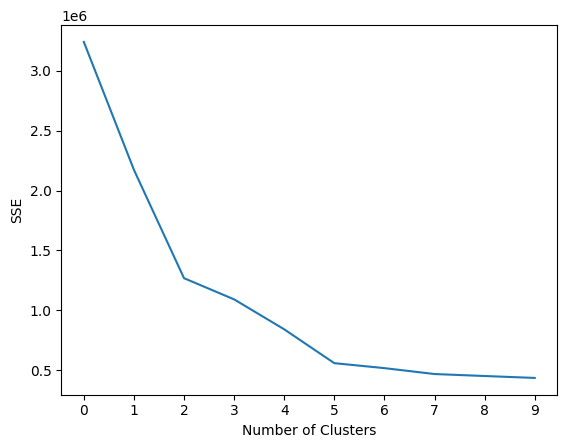

In [ ]:
# K_means clustering
from sklearn.cluster import KMeans

#Find optimum number of clusters
sse = [] #SUM OF SQUARED ERROR
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(feat_array_scaled)
    sse.append(km.inertia_)

fig, ax = plt.subplots()
ax.set(xlabel = "Number of Clusters", ylabel = "SSE", xticks = [0,1,2,3,4,5,6,7,8,9,10,11])

ax.plot(sse)

plt.show()

In [ ]:
# K_means clustering
from sklearn.cluster import KMeans

km = KMeans(n_clusters = 5, init='k-means++', n_init=50, max_iter=300,
            tol=0.0001, random_state=42)

clusters = km.fit(feat_array_scaled)
feats_df["cluster"] = clusters.labels_

In [ ]:
feats_df.head(2)

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.12900,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,1
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/05-09-2024_all_images/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.19119,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,1


In [ ]:
ua_ui = np.array(feats_df["Ua"].astype(float))/np.array(feats_df["Ui"].astype(float))
da_di = np.array(feats_df["Da"].astype(float))/np.array(feats_df["Di"].astype(float))
ga_gi = np.array(feats_df["Ga"].astype(float))/np.array(feats_df["Gi"].astype(float))
ua_ui_ga_gi = ua_ui / ga_gi
da_di_ba = da_di /  np.array(feats_df["Ba"].astype(float))

feats_df["ua_ui"] = ua_ui
feats_df["da_di"] = da_di
feats_df["ga_gi"] = ga_gi
feats_df["ua_ui_ga_gi"] = ua_ui_ga_gi
feats_df["da_di_ba"] = da_di_ba


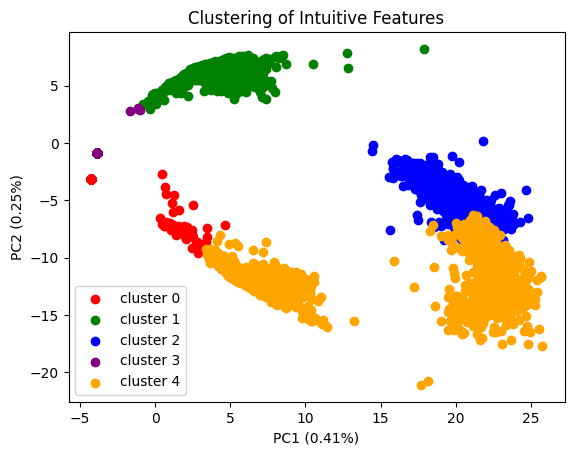

In [ ]:
clusters = np.unique(np.array(feats_df["cluster"])) # list of unique clusters

cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = feats_df[feats_df["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)


# plot the data

fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]
for j in clusters:
  df = cluster_dfs[j]
  ax.scatter(df["pc1"], df["pc2"], c = colors[j], label = "cluster " + str(j))


leg = ax.legend(loc="lower left")

ax.set(xlabel = "PC1 (0.41%)", ylabel = "PC2 (0.25%)", title = "Clustering of Intuitive Features")
plt.show()




In [ ]:
# c2 = cluster_dfs[3]

# c2[c2["pc1"] >= 17]

In [ ]:
# c_no_pattern = feats_df[feats_df["Mean"] == 0.0]
# c_all_pattern = feats_df[feats_df["Mean"] == 255.0]
# cluster_dfs = (c_no_pattern, c_all_pattern)

# print(c_no_pattern.shape)
# print(c_all_pattern.shape)

(10707, 66)
(12585, 66)


In [ ]:
# c_pat_1 = feats_df[feats_df["Mean"] != 0.0]
# c_patterns = c_pat_1[c_pat_1["Mean"] != 255.0]

In [ ]:
counter = 0
for cluster in cluster_dfs:
  print("cluster " + str(counter) + ": " + str(cluster.shape[0]))
  counter += 1

cluster 0: 10716
cluster 1: 10969
cluster 2: 908
cluster 3: 9400
cluster 4: 1777


In [ ]:
counter = 0
for cluster in cluster_dfs:
  print("cluster " + str(counter) + ": " + str(cluster.shape[0]))
  counter += 1

cluster 0: 10716
cluster 1: 10969
cluster 2: 908
cluster 3: 9400
cluster 4: 1777


In [ ]:
counter = 0
for cluster in cluster_dfs:
  print("cluster " + str(counter) + ": " + str(cluster.shape[0]))
  counter += 1

cluster 0: 10716
cluster 1: 10969
cluster 2: 908
cluster 3: 9400
cluster 4: 1777


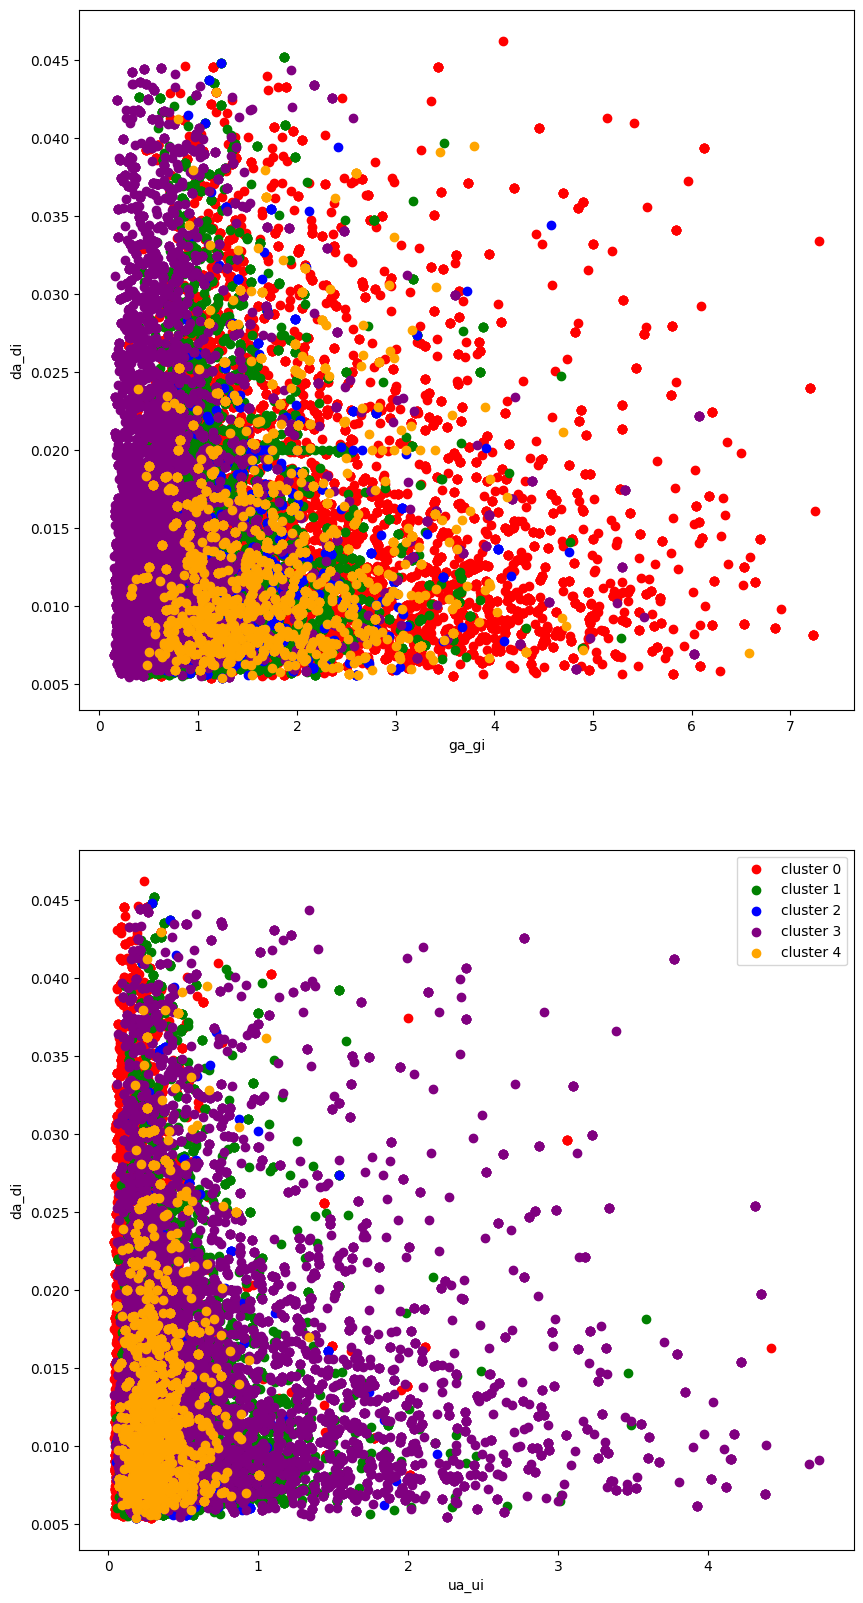

In [ ]:
# plot the data for different features

fig, ax = plt.subplots(2)



feat_1 = "ga_gi"

feat_2 = "da_di"

feat_3 = "ua_ui"

feat_4 = "da_di"

colors = ["red","green","blue","purple","orange","black","pink"]
alpha = [1,1,1,1,1]

# for j in clusters:
for j in range(len(clusters)):
  df = cluster_dfs[j]
  ax[0].scatter(df[feat_1], df[feat_2], c = colors[j], label = "cluster " + str(j), alpha = alpha[j])
  ax[1].scatter(df[feat_3], df[feat_4], c = colors[j], label = "cluster " + str(j), alpha = alpha[j])
  ax[0].set(xlabel = feat_1, ylabel = feat_2)
  ax[1].set(xlabel = feat_3, ylabel = feat_4)


leg = plt.legend(loc="upper right")

# ax.set(xlabel = feat_1, ylabel = feat_2)
# ax.set(xlabel = feat_1, ylabel = feat_2, xlim = (0.007,0.013), ylim = (0,1.6)) # Da vs Di
# ax.set(xlabel = feat_1, ylabel = feat_2, xlim = (0.02,0.18), ylim = (0.02,0.18)) # Ga vs Gi
fig.set_figwidth(10)
fig.set_figheight(20)
plt.show()


In [ ]:
c0 = cluster_dfs[0]

c0 = c0[c0["ua_ui"] >= 3]

c0.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,ua_ui,da_di,ga_gi,ua_ui_ga_gi,da_di_ba
1059,0.051668,0.011683,0.147524,0.049487,-0.056768,0.010242,0.628521,0,2,5094.png,5094,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,4.422624,0.016296,2.981087,1.483561,-0.287056
3682,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,20589.0,noise 3 20589.0.png,20589.0,/content/Generated Images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,3.061933,0.029584,5.304882,0.577192,-0.198871
4081,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,7,noise 7 20589.0.png,20589.0,/content/Generated_Images_7-2-24/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,3.061933,0.029584,5.304882,0.577192,-0.198871
4104,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,4,noise 4 20589.0.png,20589.0,/content/Generated_Images_7-2-24/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0

In [ ]:
feats_df = feats_df[feats_df["seed"] == 20589]

feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,ua_ui,da_di,ga_gi,ua_ui_ga_gi,da_di_ba
13333,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,20589.0,noise 3 20589.0.png,20589.0,/content/Generated Images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,3.061933,0.029584,5.304882,0.577192,-0.198871
14502,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,7,noise 7 20589.0.png,20589.0,/content/Generated_Images_7-2-24/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,3.061933,0.029584,5.304882,0.577192,-0.198871
14569,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,4,noise 4 20589.0.png,20589.0,/content/Generated_Images_7-2-24/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,3.061933,0.029584,5.304882,0.577192,-0.198871
21607,0.042836,0.01399,0.157065,0.029608,-0.148759,0.008856,0.299359,0,6,noise 6 20589.0.png,20589.0,/content/Generated_Images_7-2-24/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,

In [ ]:
c4 = cluster_dfs[4]

c4 = c4[c4["Ga"].astype(float) <= 0.07]
c4 = c4[c4["Gi"].astype(float) >= 0.15]

c4.head()




,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster
166,0.016817,0.164614,0.060487,0.154467,-0.091441,0.009182,0.383878,1,2,4508.png,4508,/content/05-09-2024_all_images/,1,7,197.032,255,4415.285714,9082.504056,92.162571,33.982536,150.1720,37.985833,285.061857,494.895281,64.714286,47.652655,129.142857,57.613065,52.714286,63.247167,47.428571,63.583145,54.976429,66.789981,41.607143,50.189624,94.301143,63.661788,0.782,0.266057,65.727286,90.90461,1.125898e+06,2.316039e+06,100.0,0.0,1.125898e+06,2.316039e+06,65.714286,47.921705,141.142857,63.8736,90.165143,57.547529,47.254,63.656347,1.304714,0.290276,0.801429,0.159684,0.908,0.082457,7,57.968,0,1299.000000,2863.357520,75.161857,71.856785,53.722571,43.612161,244.874143,457.229106,54.571429,73.783190,32.142857,24.993877,41.714286,65.434186,38.714286,51.266013,31.238286,35.534640,19.443571,29.606639,64.206286,44.940362,0.421714,0.280211,53.109000,75.226589,331245.0,730156.167528,100.0,0.0,331245.0,730156.167528,56.428571,73.682441,58.285714,62.495061,66.131857,42.155000,31.771286,52.346730,2.545143,1.374956,0.485143,0.186068,0.651429,0.204589,22.485529,10.459658,4
229,0.009539,0.162624,0.055791,0.166881,-0.128496,0.009368,0.841211,1,2,5987.png,5987,/content/05-09-2024_all_images/,1,1,253.470,255,39760.000000,0.000000,99.444000,0.000000,99.4410,0.000000,795.799000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,226.771000,0.000000,223.238000,0.000000,44.873000,0.000000,0.789,0.000000,282.843000,0.00000,1.013880e+07,0.000000e+00,100.0,0.0,1.013880e+07,0.000000e+00,0.000000,0.000000,200.000000,0.0000,45.000000,0.000000,200.000,0.000000,1.016000,0.000000,0.984000,0.000000,0.997,0.000000,1,1.530,0,240.000000,0.000000,192.192000,0.000000,192.629000,0.000000,62.971000,0.000000,182.000000,0.000000,183.000000,0.000000,18.000000,0.000000,17.000000,0.000000,19.433000,0.000000,15.725000,0.000000,25.921000,0.000000,0.761000,0.000000,23.345000,0.000000,61200.0,0.000000,100.0,0.0,61200.0,0.000000,184.000000,0.000000,200.000000,0.000000,46.736000,0.000000,17.000000,0.000000,1.236000,0.000000,0.809000,0.000000,0.923000,0.000000,4.316883,8.002617,4
262,0.022591,0.133198,0.05967,0.159736,-0.051195,0.011345,0.970512,1,2,6522.png,6522,/content/05-09-2024_all_images/,1,1,254.012,255,39845.000000,0.000000,100.060000,0.000000,100.2040,0.000000,801.213000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.436000,0.000000,225.041000,0.000000,119.891000,0.000000,0.780,0.000000,282.8430

In [ ]:
c2_means = np.array(cluster_dfs[2]["Mean"])

feats = [
    "Ua","Ui","Ga","Gi","Da","Di","Ba","Mean",	"Median",	"Area_mean",	"Area_std",	"X_mean",	"X_std",	"Y_mean",
    "Y_std",	"Perim._mean",	"Perim._std",	"BX_mean",	"BX_std",	"BY_mean",
    "BY_std",	"Width_mean",	"Width_std",	"Height_mean",	"Height_std",
    "Major_mean",	"Major_std",	"Minor_mean",	"Minor_std",	"Angle_mean",
    "Angle_std",	"Circ._mean",	"Circ._std",	"Feret_mean",	"Feret_std",
    "IntDen_mean",	"IntDen_std",	"%Area_mean",	"%Area_std",	"RawIntDen_mean",
    "RawIntDen_std",	"FeretX_mean",	"FeretX_std",	"FeretY_mean",	"FeretY_std",
    "FeretAngle_mean",	"FeretAngle_std",	"MinFeret_mean",	"MinFeret_std",
    "AR_mean",	"AR_std",	"Round_mean",	"Round_std",	"Solidity_mean",	"Solidity_std",
    "num_spots"
]

rows = {"0":[],"1":[],"2":[],"3":[],"4":[]}

for i in range(len(cluster_dfs)):
  df = cluster_dfs[i]
  for feat in feats:
    mean_val = np.mean(np.array(df[feat].astype(float)))
    rows[str(i)].append(mean_val)
    # print("Cluster " + str(i) + " avg " + feat + ": " + str(mean_val))





In [ ]:
cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df.head()

,Ua,Ui,Ga,Gi,Da,Di,Ba,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots
0,0.025090,0.139637,0.124614,0.088095,0.010005,0.870887,-0.100506,254.975990,255.000000,39996.233669,0.000000,100.004211,0.000000,99.999399,0.000000,797.673679,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.669786,0.000000,225.660188,0.000000,0.833310,0.000000,0.789895,0.000000,282.843000,0.000000,1.019904e+07,0.000000e+00,100.000000,0.0,1.019904e+07,0.000000e+00,0.000000,0.000000,0.018664,0.000000,134.991601,0.000000,200.000000,0.000000,1.000046,0.000000,0.999956,0.000000,0.999907,0.000000,1.000000
1,0.030987,0.091589,0.098943,0.105639,0.009951,0.874576,-0.129454,42.395659,8.996718,72.205003,34.871946,100.556385,59.470241,99.559751,59.827728,26.261410,6.498977,96.525776,59.478276,95.539788,59.796854,8.058007,2.213768,8.038457,2.252956,9.139328,2.302878,7.304438,1.686126,64.796639,54.711238,0.959916,0.052586,9.925075,2.340550,1.841228e+04,8.892346e+03,100.000000,0.0,1.841228e+04,8.892346e+03,97.324769,59.590018,98.106206,60.034552,109.537981,39.137525,7.200168,1.792069,1.252629,0.316383,0.844732,0.143812,0.928757,0.033562,116.272404
2,0.032507,0.110781,0.118402,0.090595,0.009978,0.907298,-0.123519,123.918339,109.245595,415.754952,504.763296,100.369940,62.001567,99.662065,63.353696,88.338233,88.904078,88.938649,62.563591,88.391031,64.029520,22.785847,17.058283,22.570507,17.394698,26.073677,16.270898,13.965282,6.949270,84.609178,54.380313,0.739480,0.217198,29.647201,21.411801,1.060175e+05,1.287146e+05,100.000000,0.0,1.060175e+05,1.287146e+05,90.530113,62.873992,98.586682,64.856935,96.049988,48.526228,16.345301,11.055613,1.877354,0.786785,0.619234,0.195498,0.867023,0.114363,74.091410
3,0.033350,0.087220,0.064016,0.110666,0.010069,0.810102,-0.130102,0.000003,0.000000,39982.979255,0.000000,99.977713,0.000000,99.981064,0.000000,799.660928,0.000000,0.020000,0.000000,0.023404,0.000000,199.915426,0.000000,199.915319,0.000000,225.580568,0.000000,225.580448,0.000000,0.000000,0.000000,0.785091,0.000000,282.723330,0.000000,1.356383e-01,0.000000e+00,0.042553,0.0,1.356383e-01,0.000000e+00,0.020000,0.000000,0.023404,0.000000,135.001961,0.000000,199.915319,0.000000,1.000106,0.000000,0.999947,0.000000,1.000000,0.000000,0.000426
4,0.032697,0.115894,0.118644,0.084592,0.009903,0.920787,-0.120915,197.684876,238.497468,20759.037003,4791.221848,102.584240,28.779363,102.179816,29.786908,698.889980,305.277395,36.293273,33.295812,35.864247,34.080740,132.572062,34.451099,132.554889,34.427783,137.425955,31.958068,131.732158,30.287168,89.423135,20.908422,0.571655,0.136125,186.242704,47.219219,5.293554e+06,1.221762e+06,100.000000,0.0,5.293554e+06,1.221762e+06,37.113815,33.475720,68.144506,34.037445,108.559336,17.936317,130.533325,34.251413,1.313990,0.261034,0.846804,0.089104,0.856152,0.055402,4.328644


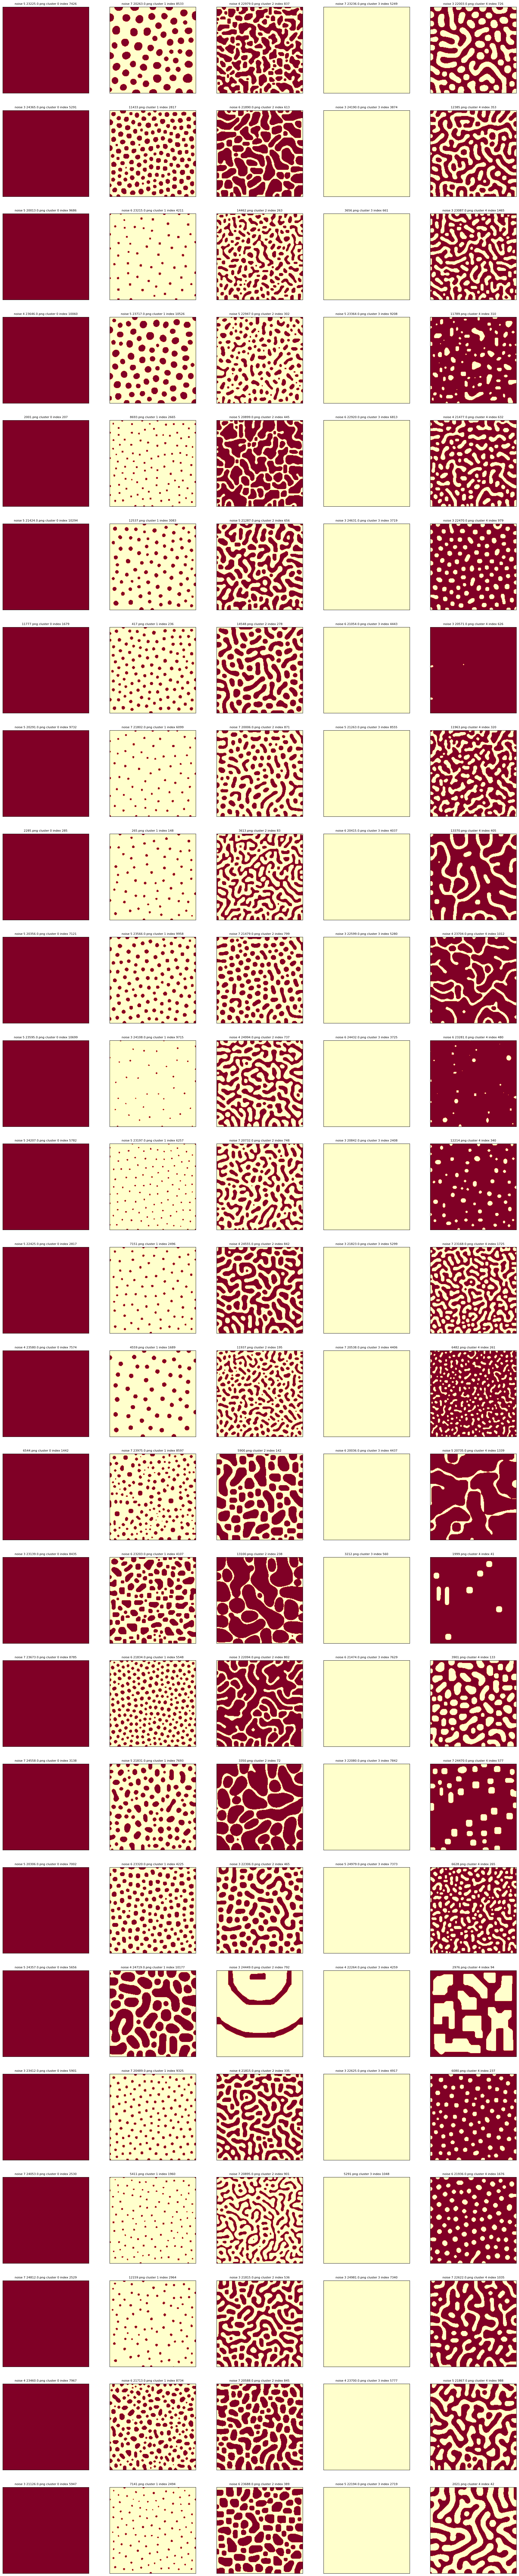

In [ ]:
# print out random images from clusters

num_imgs = 25

fig, ax = plt.subplots(num_imgs, len(cluster_dfs))

for i in range(num_imgs):
  for j in range(len(cluster_dfs)):
    df = cluster_dfs[j]
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    img = np.array(Image.open(df["dir"][num] + df["path"][num]))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 8)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)


fig.set_figwidth(5*len(cluster_dfs))
fig.set_figheight(5 * num_imgs)
plt.show()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,ua_ui,da_di,ga_gi,ua_ui_ga_gi,da_di_ba
1059,0.051668,0.011683,0.147524,0.049487,-0.056768,0.010242,0.628521,0,2,5094.png,5094,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-4.257723,3.136623,0,4.422624,0.016296,2.981087,1.483561,-0.287056


[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


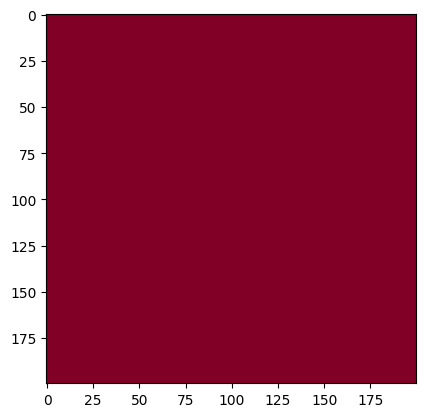

In [ ]:
# example: easy to pull up features and params from an individual interesting sim

cluster = 0
index = 1059

df = cluster_dfs[cluster]

display(pd.DataFrame(df.iloc[index]).transpose())

# show the image for confirmation

fig, ax = plt.subplots()

im = np.array(Image.open(df["dir"][index]+ df["path"][index]))
print(im)
ax.imshow(im, cmap = "YlOrRd", vmin = 0, vmax = 255)

plt.show()


2024-12-15 Re-doing the plotting

In [ ]:
# with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-19_feat_array_unscaled.pkl", 'rb') as f:
#   test_df = pickle.load(f) # deserialize using load()

# test_df.columns

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
# scale each param so we can plot them next to each other
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
params_df = feats_df[params]

from sklearn.preprocessing import MinMaxScaler


for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled


feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

feats_extra = []

for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra
print(len(feats))

num_classes = 5
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []


for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(std)

    # print("Cluster " + str(i) + " avg " + feat + ": " + str(mean_val))


cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df


28


,Ua_scaled mean,Ua_scaled min,Ua_scaled max,Ua_scaled std,Ui_scaled mean,Ui_scaled min,Ui_scaled max,Ui_scaled std,Ga_scaled mean,Ga_scaled min,Ga_scaled max,Ga_scaled std,Gi_scaled mean,Gi_scaled min,Gi_scaled max,Gi_scaled std,Da_scaled mean,Da_scaled min,Da_scaled max,Da_scaled std,Di_scaled mean,Di_scaled min,Di_scaled max,Di_scaled std,Ba_scaled mean,Ba_scaled min,Ba_scaled max,Ba_scaled std
0,0.386602,0.000000,1.000000,0.265635,0.648173,0.001357,1.000000,0.223516,0.663908,0.038978,1.000000,0.215958,0.422974,0.000126,0.999567,0.281080,0.501570,0.000005,1.000000,0.272996,0.496566,0.000000,0.999242,0.271634,0.618869,0.000721,1.000000,0.260061
1,0.522644,0.000170,0.999883,0.236615,0.407837,0.006080,0.999152,0.221542,0.492626,0.004264,0.999983,0.197569,0.536495,0.000477,1.000000,0.230008,0.488026,0.000292,0.999981,0.264014,0.499531,0.000054,0.999396,0.259930,0.442225,0.000000,0.998024,0.234448
2,0.557693,0.014521,0.995799,0.240419,0.503834,0.034954,0.998778,0.234926,0.622457,0.047766,0.999993,0.226336,0.439154,0.001581,1.000000,0.238869,0.494796,0.000000,0.998663,0.272421,0.525833,0.000841,0.999396,0.272587,0.478440,0.002843,0.983150,0.247130
3,0.577139,0.000725,0.999950,0.255847,0.385983,0.000000,0.999724,0.287983,0.259589,0.000000,0.999993,0.220504,0.569026,0.000000,0.999869,0.256692,0.517414,0.000165,0.999666,0.268630,0.447707,0.000133,0.998887,0.276193,0.438273,0.000541,0.999914,0.258069
4,0.562068,0.002266,0.997429,0.258180,0.529412,0.040955,0.998636,0.217159,0.624073,0.067900,0.999486,0.218039,0.400308,0.000959,0.999914,0.242834,0.475919,0.000365,0.999007,0.269585,0.536676,0.001980,1.000000,0.267575,0.494331,0.002523,0.998014,0.256619


In [ ]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,Ua_scaled,Ui_scaled,Ga_scaled,Gi_scaled,Da_scaled,Di_scaled,Ba_scaled
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,1,0.387342,0.268942,0.312573,0.540951,0.296555,0.288368,0.541828
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/05-09-2024_all_images/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,1,0.603087,0.249604,0.371563,0.502405,0.213181,0.483059,0.423171
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/05-09-2024_all_images/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.

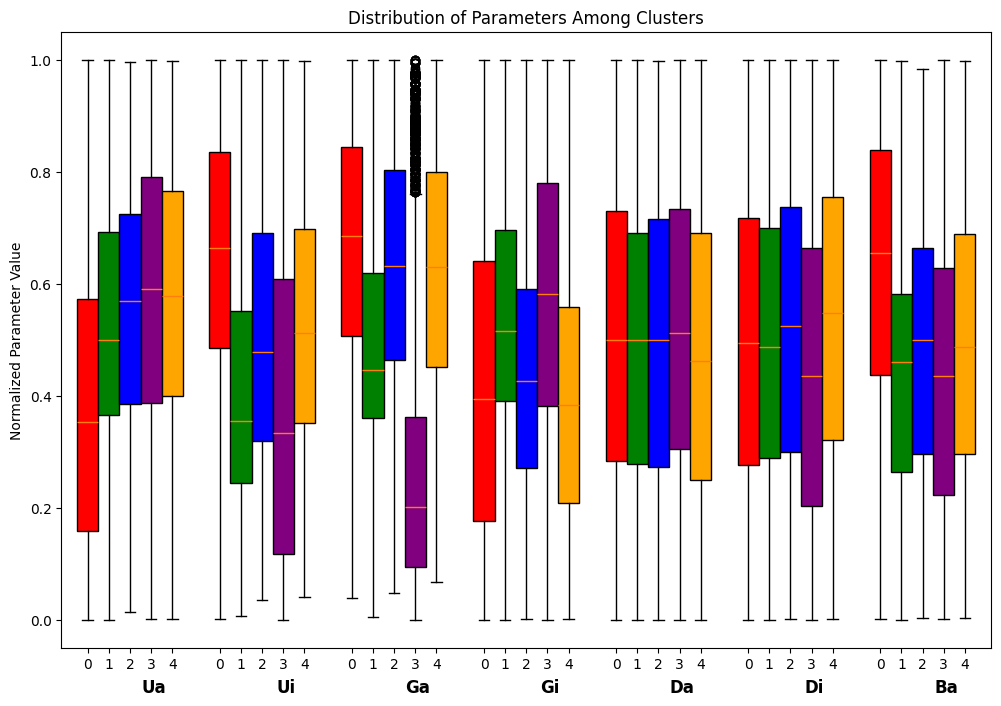

In [ ]:
# Do all 7 main params on the same plot

# print bar plots for each param based on class

feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']
num_classes = 5
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)

colors = ["red","green","blue","purple","orange","turquoise","pink"]
fig, ax = plt.subplots(figsize = (12,8))

for i in range(len(class_dfs)):
  df = class_dfs[i]

  #   # bar plots
  #   width = 0.32
  #   # fig, ax = plt.subplots()
  #   bar_pos = (np.array([0,3,6,9,12]) + width*i )


  data = [
      df["Ua_scaled"],
      df["Ui_scaled"],
      df["Ga_scaled"],
      df["Gi_scaled"],
      df["Da_scaled"],
      df["Di_scaled"],
      df["Ba_scaled"]
      ]
  ax.boxplot(data, labels = [str(i), str(i), str(i), str(i), str(i), str(i), str(i)],
             positions=[1 + 0.4*i,3.5 + 0.4*i,6 + 0.4*i,8.5 + 0.4*i,11 + 0.4*i,13.5 + 0.4*i,16 + 0.4*i], widths=0.4, patch_artist=True, boxprops=dict(facecolor=colors[i]))



# ax.set(title = "Mean Params By Classes")

# leg = ax.legend(['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
#         'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled'], loc="upper left")
# leg = ax.get_legend()
# leg.legendHandles[0].set_color('red')
# leg.legendHandles[1].set_color('green')
# leg.legendHandles[2].set_color('blue')
# leg.legendHandles[3].set_color('purple')
# leg.legendHandles[4].set_color('orange')
# leg.legendHandles[5].set_color('turquoise')
# leg.legendHandles[6].set_color('pink')


# Add general group labels below the axis
group_positions = [(2.25, 'Ua'), (4.75, 'Ui'),(7.25, 'Ga'), (9.75, 'Gi'),(12.25, 'Da'), (14.75, 'Di'),(17.25,"Ba")]  # Midpoints of groups and their labels
for pos, label in group_positions:
    ax.text(pos, -0.12, label, ha='center', va='center', fontsize=12, fontweight='bold', transform=ax.transData)
# ax.set_xticks([1,4,7,10,13])
# ax.set_xticklabels(["0",'1', '2', '3', '4'])

ax.set(ylabel = "Normalized Parameter Value", title = "Distribution of Parameters Among Clusters")

plt.show()







In [ ]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,Ua_scaled,Ui_scaled,Ga_scaled,Gi_scaled,Da_scaled,Di_scaled,Ba_scaled
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,1,0.387342,0.268942,0.312573,0.540951,0.296555,0.288368,0.541828
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/05-09-2024_all_images/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,1,0.603087,0.249604,0.371563,0.502405,0.213181,0.483059,0.423171
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/05-09-2024_all_images/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.

In [ ]:
single_dic["Ua"].head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std
0,0.0067,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14735.png,14735,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.006834343434343434,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14736.png,14736,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.006968686868686869,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14737.png,14737,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.007103030303030303,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14738.png,14738,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.007237373737373738,0.07,0.08,0.1,-0.12,0.01,0.5,0,2,14739.png,14739,/content/05-09-2024_all_images/,1,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0

In [ ]:
feats_df["full_path"] = feats_df["dir"] + feats_df["path"]
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,Ua_scaled,Ui_scaled,Ga_scaled,Gi_scaled,Da_scaled,Di_scaled,Ba_scaled,full_path
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/05-09-2024_all_images/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.196009,6.000280,1,0.387342,0.268942,0.312573,0.540951,0.296555,0.288368,0.541828,/content/05-09-2024_all_images/1.png
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/05-09-2024_all_images/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,2.398773,6.018919,1,0.603087,0.249604,0.371563,0.502405,0.213181,0.483059,0.423171,/content/05-09-2024_all_images/3.png
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/05-09-2024_all_images/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209

In [ ]:
feats_df["full_path"][1]

'/content/05-09-2024_all_images/3.png'

In [ ]:
# load in the single param dfs

with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-28_single_param_scans.pkl", 'rb') as f:
  single_dic = pickle.load(f) # deserialize using load()

# merge tge dataframes
for i in single_dic.keys():
  df = single_dic[i]
  df["full_path"] = df["dir"] + df["path"]
  result_inner = pd.merge(single_dic[i], feats_df, on='full_path', how='inner')
  single_dic[i] = result_inner

In [ ]:
# # Da = single_dic["Da"]

# Da["full_path"] = Da["dir"] + Da["path"]
# result_inner = pd.merge(Da, feats_df, on='full_path', how='inner')

# Da.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,full_path
0,0.03,0.07,0.08,0.1,-0.12,0.0,0.5,1,2,13935.png,13935,/content/05-09-2024_all_images/,1,841,11.405,0,2.127229,1.273244,99.792512,60.979133,101.008194,60.989220,4.612964,1.956731,99.019025,60.948602,100.236623,60.999385,1.542212,0.754496,1.549346,0.796994,2.075556,0.917534,1.255452,0.297827,31.600386,46.043703,0.966610,0.090659,2.251873,0.884468,542.443520,324.677108,100.0,0.0,542.443520,324.677108,99.029727,60.956489,100.411415,61.017606,129.145205,26.717478,1.208134,0.450298,1.668145,0.717156,0.704363,0.262733,0.967620,0.081595,1,243.595,255,38211.0,0.0,100.008,0.0,100.006,0.0,837.421,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,220.677,0.0,220.466,0.0,36.418,0.0,0.685,0.0,282.136,0.0,9743805.0,0.0,100.0,0.0,9743805.0,0.0,0.0,0.0,0.0,0.0,134.856,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.955,0.0,/content/05-09-2024_all_images/13935.png
1,0.03,0.07,0.08,0.1,-0.12,0.0012121212121212121,0.5,1,2,13936.png,13936,/content/05-09-2024_all_images/,1,450,16.008,0,5.580000,2.986496,99.702238,60.714217,99.212429,61.149281,7.379578,2.603710,98.491111,60.725694,97.988889,61.143310,2.437778,0.895368,2.444444,0.920279,2.881238,0.912335,2.285540,0.824038,35.596084,48.942480,0.986689,0.050530,3.316807,1.037997,1422.900000,761.556360,100.0,0.0,1422.900000,761.556360,98.613333,60.695354,98.255556,61.186411,125.144764,28.122555,2.194202,0.842720,1.344422,0.502668,0.813660,0.202408,0.946842,0.079702,1,238.992,255,37489.0,0.0,100.002,0.0,100.020,0.0,835.765,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,218.520,0.0,218.436,0.0,12.348,0.0,0.674,0.0,282.843,0.0,9559695.0,0.0,100.0,0.0,9559695.0,0.0,0.0,0.0,0.0,0.0,135.000,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.937,0.0,/content/05-09-2024_all_images/13936.png
2,0.03,0.07,0.08,0.1,-0.12,0.0015151515151515152,0.5,1,2,13937.png,13937,/content/05-09-2024_all_images/,1,359,16.766,0,7.325905,3.331653,99.824705,60.810466,96.995694,62.031059,8.589526,2.693714,98.445682,60.807947,95.604457,61.982921,2.768802,0.853977,2.777159,0.905220,3.267064,0.946772,2.678652,0.807533,37.849875,49.443719,0.991150,0.043223,3.798613,1.070309,1868.105850,849.571598,100.0,0.0,1868.105850,849.571598,98.554318,60.790995,95.877437,62.015736,124.304331,29.165487,2.526833,0.771767,1.261501,0.337427,0.835423,0.168024,0.953384,0.071566,1,238.234,255,37370.0,0.0,99.974,0.0,100.052,0.0,829.380,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,218.145,0.0,218.116,0.0,6.292,0.0,0.683,0.0,282.843,0.0,9529350.0,0.0,100.0,0.0,9529350.0,0.0,0.0,0.0,0.0,0.0,135.000,0.0,200.0,

In [ ]:
feats_df[feats_df["cluster"] == 3]

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,cluster,Ua_scaled,Ui_scaled,Ga_scaled,Gi_scaled,Da_scaled,Di_scaled,Ba_scaled,full_path
6,0.032611,0.066478,0.071324,0.094207,-0.137396,0.008921,0.63797,0,2,14.png,14,/content/05-09-2024_all_images/,1,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-3.855779,-0.873314,3,0.560098,0.282229,0.308346,0.462521,0.230256,0.309346,0.393766,/content/05-09-2024_all_images/14.png
19,0.035813,0.063909,0.072117,0.081002,-0.126447,0.010641,0.704652,0,2,31.png,31,/content/05-09-2024_all_images/,1,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-3.855779,-0.873314,3,0.633966,0.269378,0.313642,0.377083,0.660530,0.362946,0.460575,/content/05-09-2024_all_images/31.png
31,0.03056,0.084129,0.070238,0.096735,-0.112404,0.010934,0.533729,0,2,47.png,47,/content/05-09-2024_all_images/,1,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,255.0,255,40000.0,0.0,100.0,0.0,100.0,0.0,797.657,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.79,0.0,282.843,0.0,10200000.0,0.0,100.0,0.0,10200000.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,-3.855779,-0.873314,3,0.512794,0.370520,0.301103,0.478882,0.734003,0.225557,0.546264,/content/05-09-2024_all_images/47.png
35,0.029078,0.049194,0.071029,0.081247,-0.136953,0.010045,0.660889,0,2,55.png,55,/content/05-09-2024_all_images/,1,0,0.0,0,40000.0,0.0,100.0,0.0,100.0,0.0,800.0,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.0,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,

In [ ]:
single_dic["Ua"]["Mean_x"]

226.223

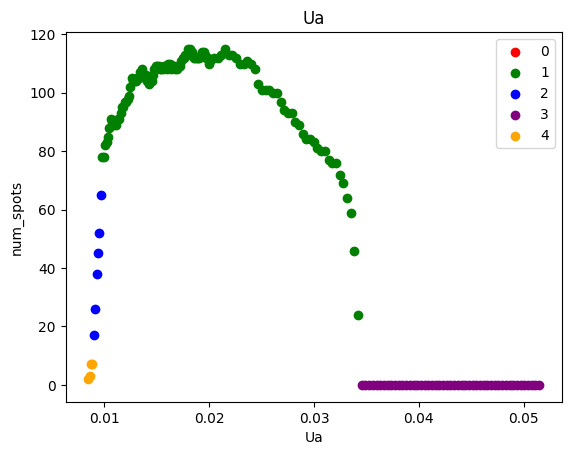

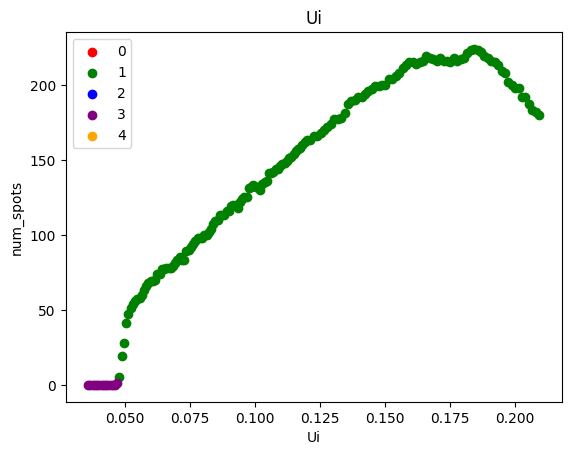

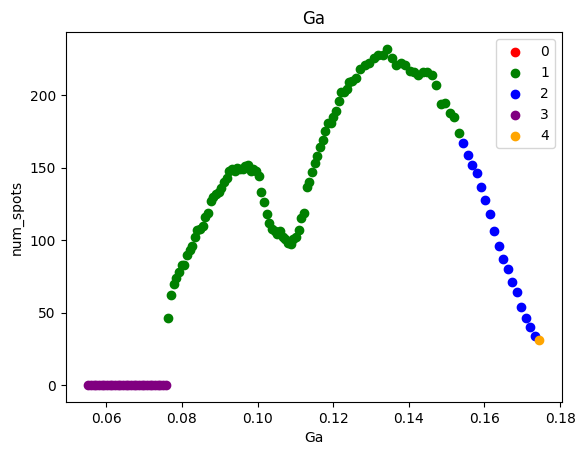

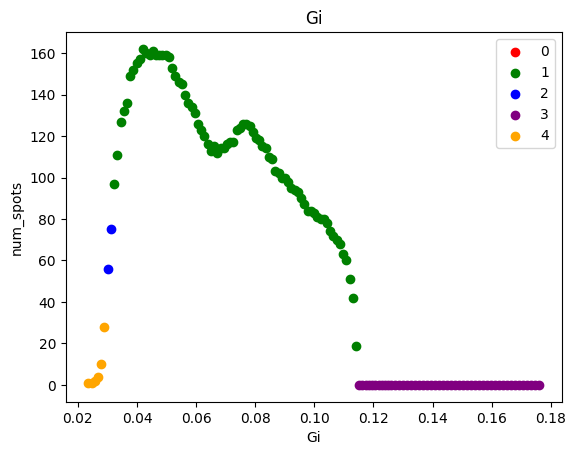

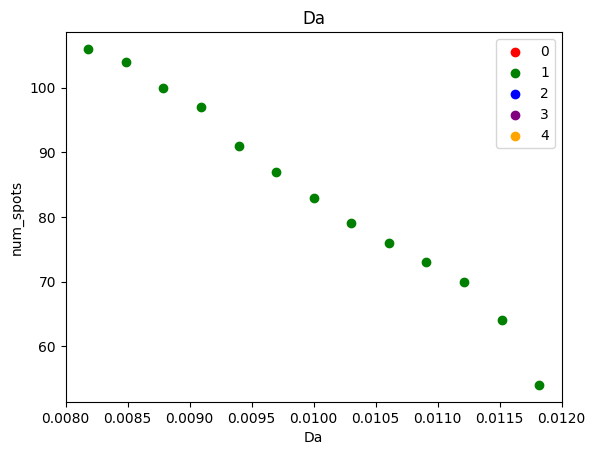

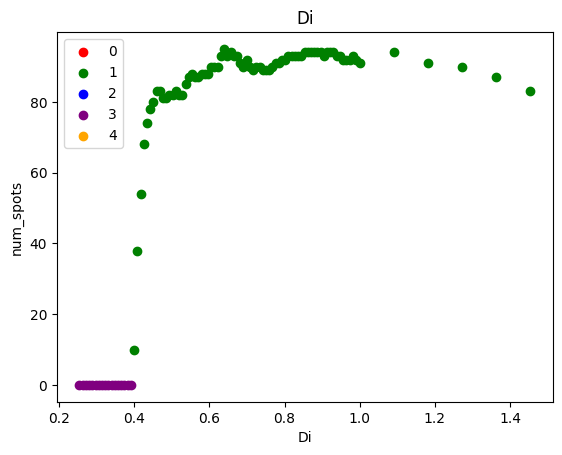

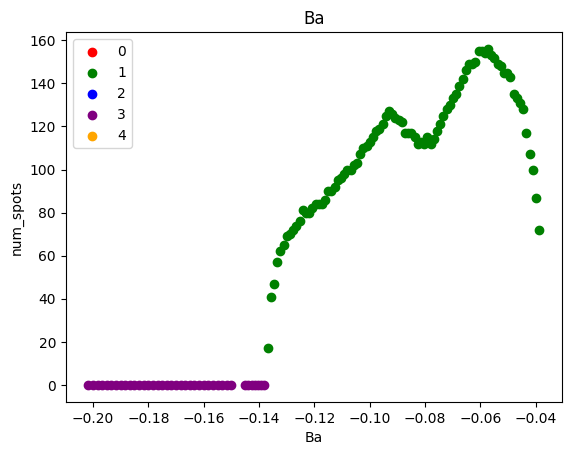

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "num_spots"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()

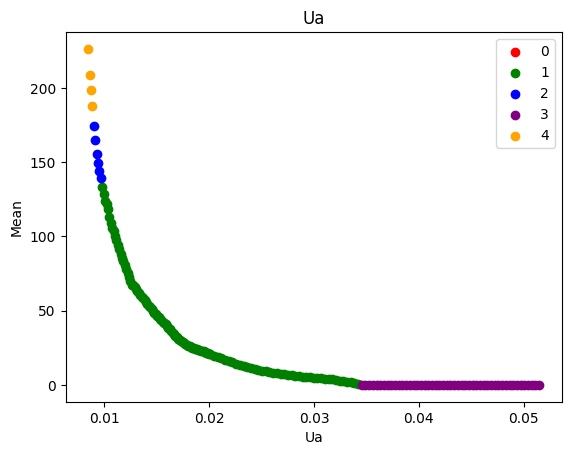

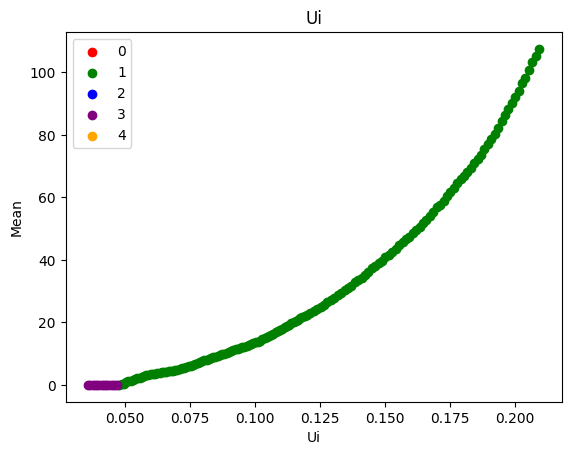

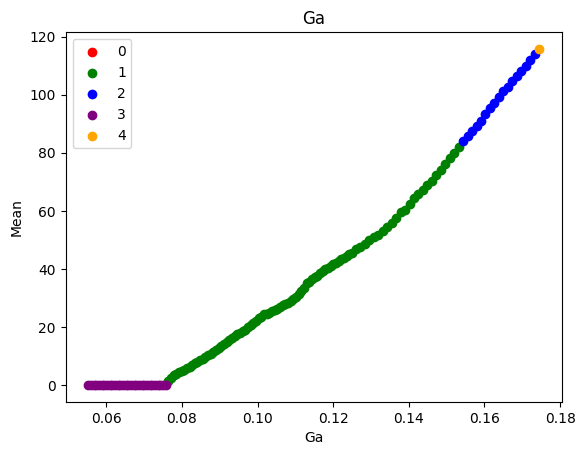

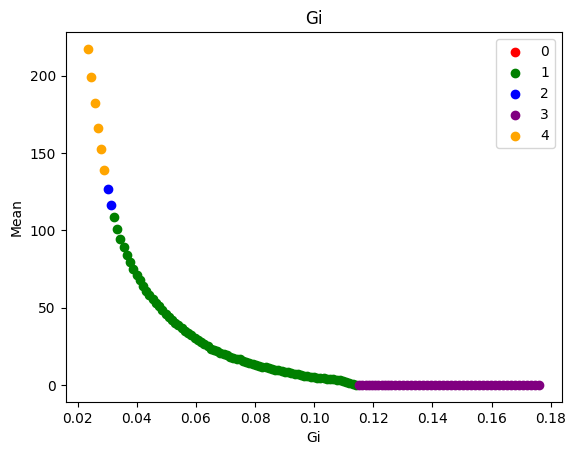

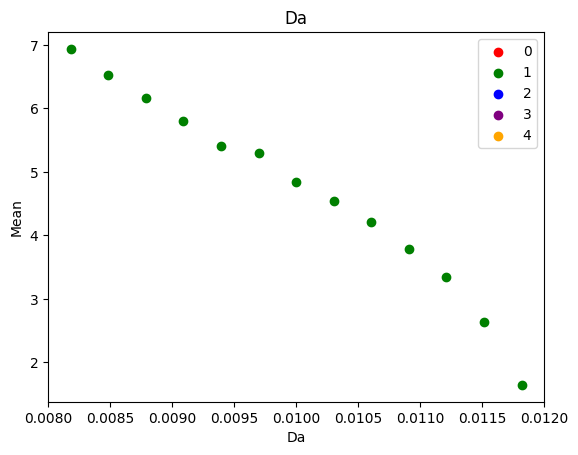

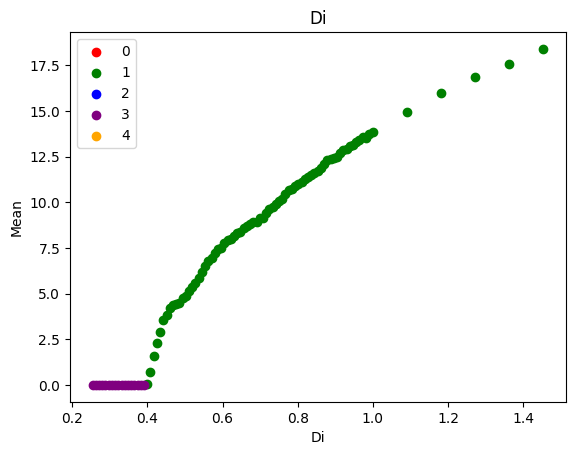

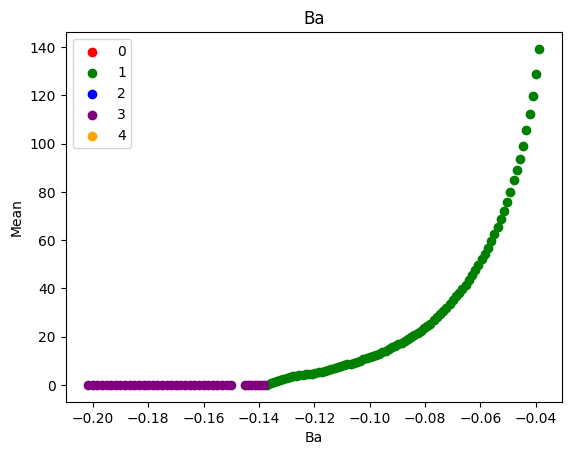

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "Mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()

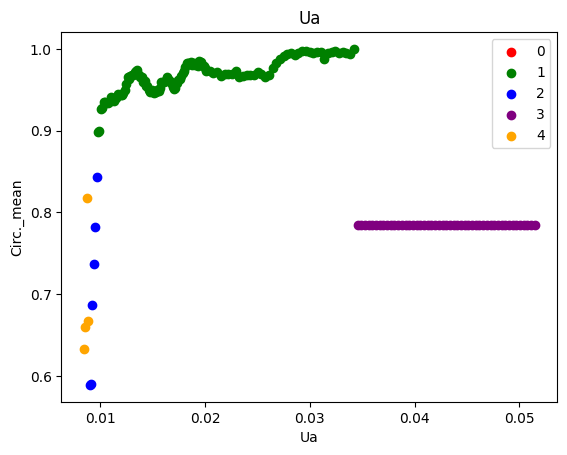

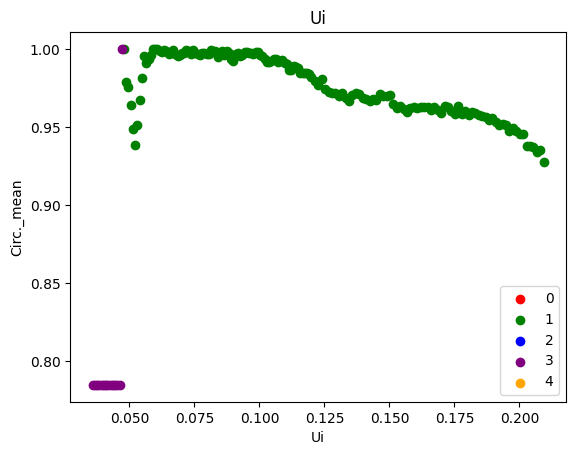

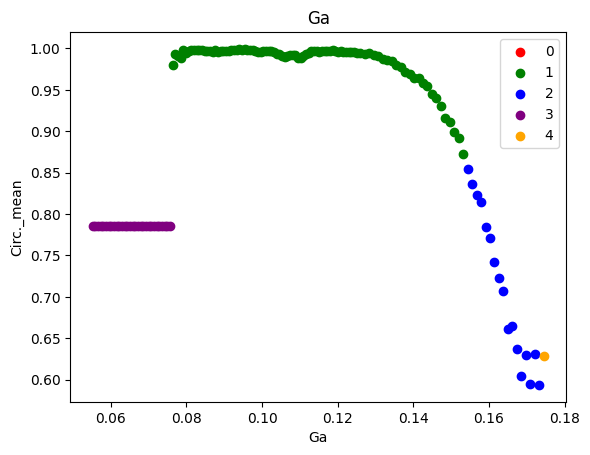

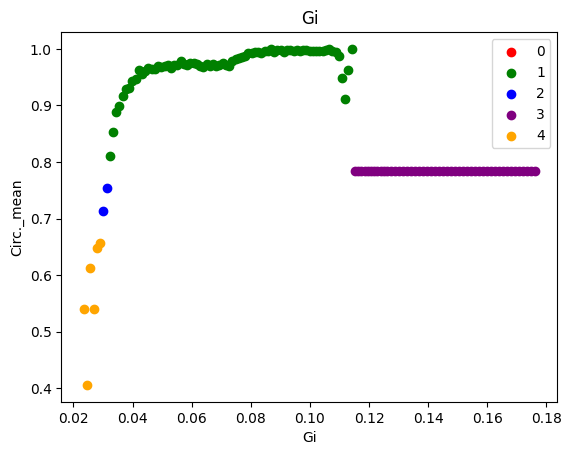

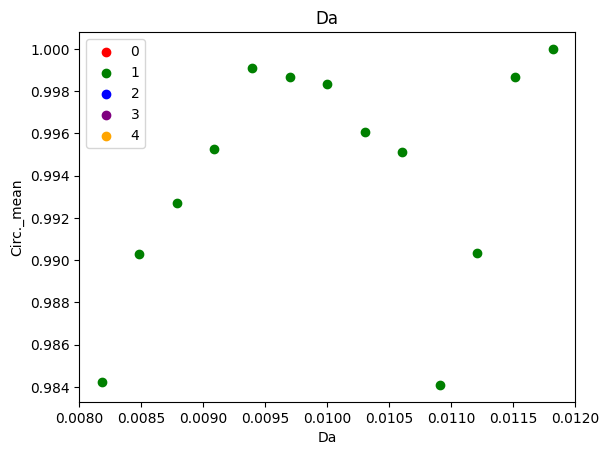

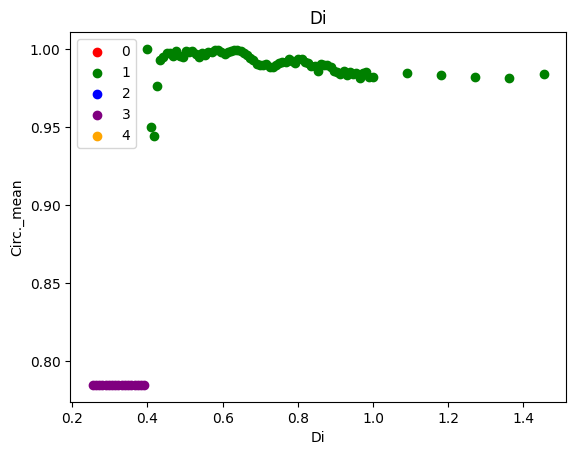

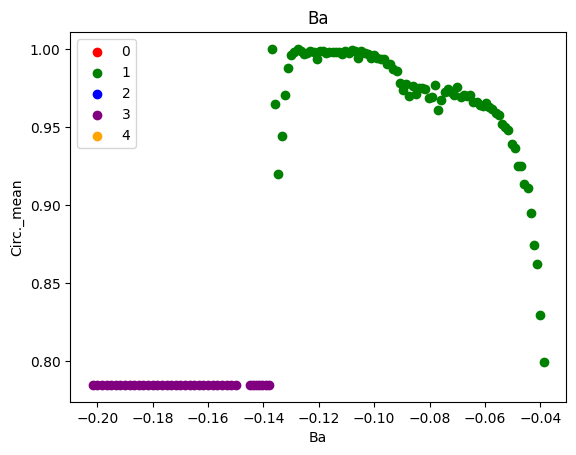

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "Circ._mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()

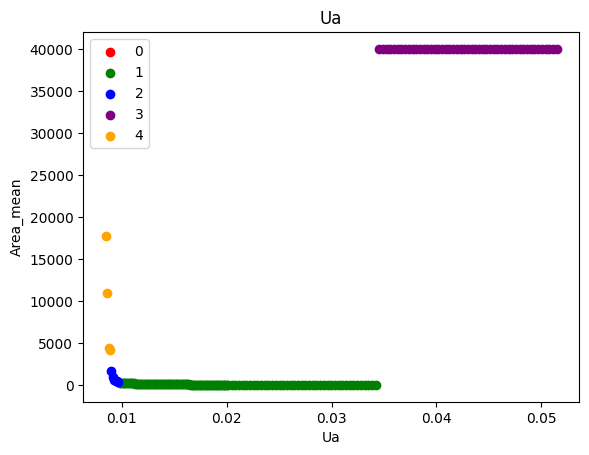

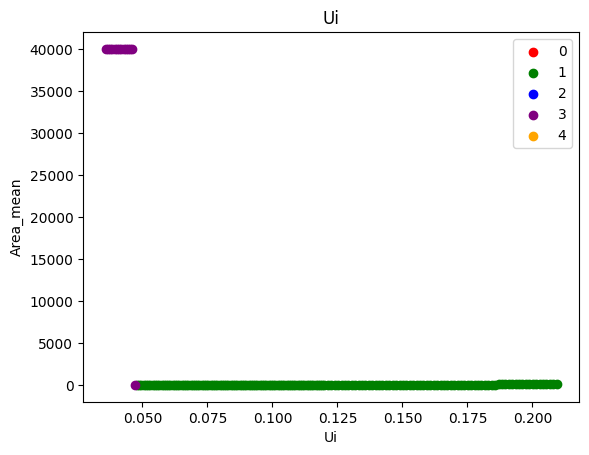

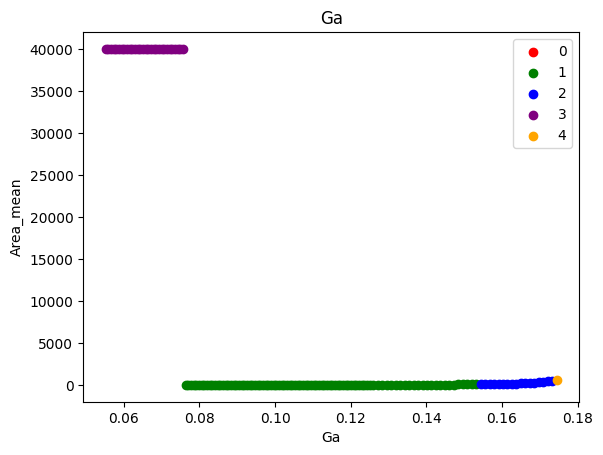

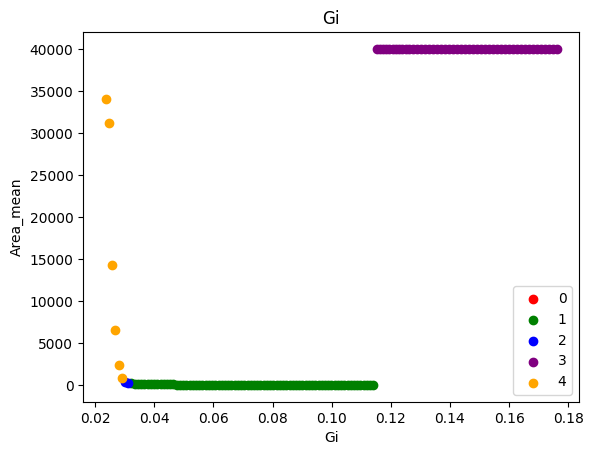

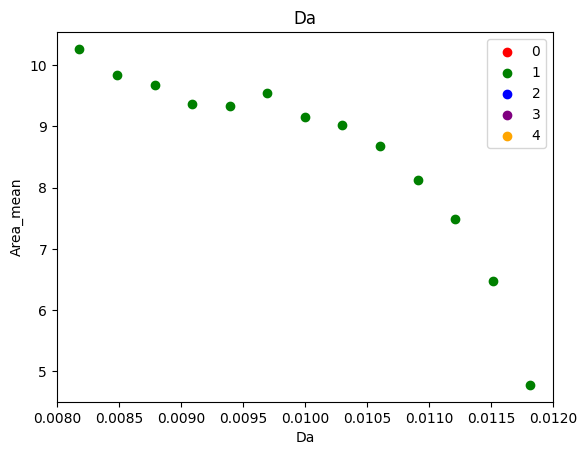

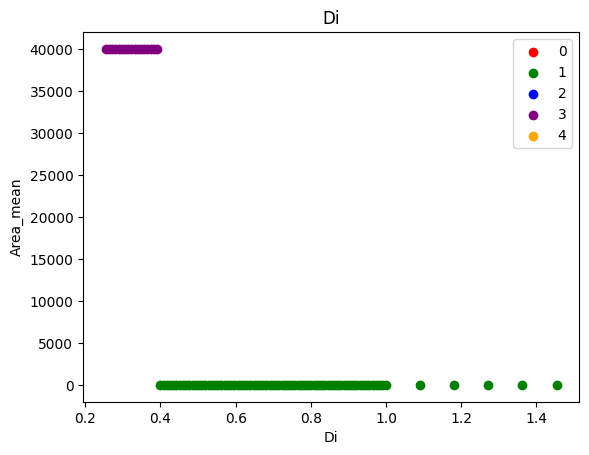

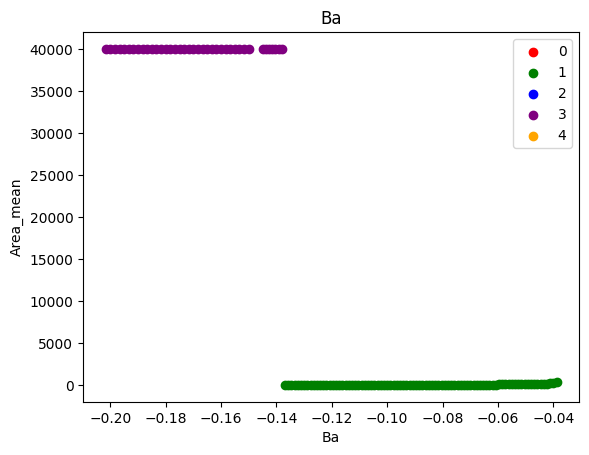

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "Area_mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in [0,1,2,3,4]:

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()

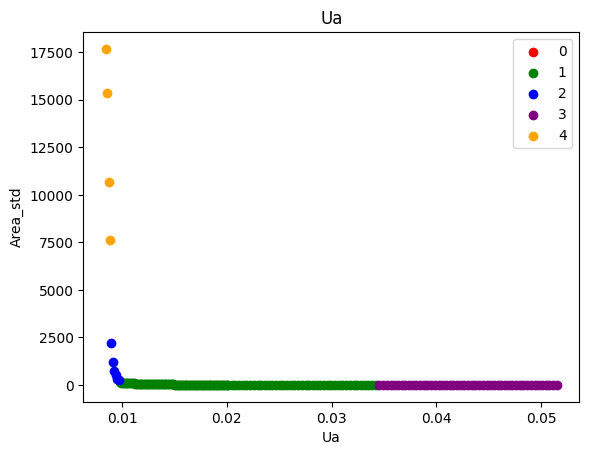

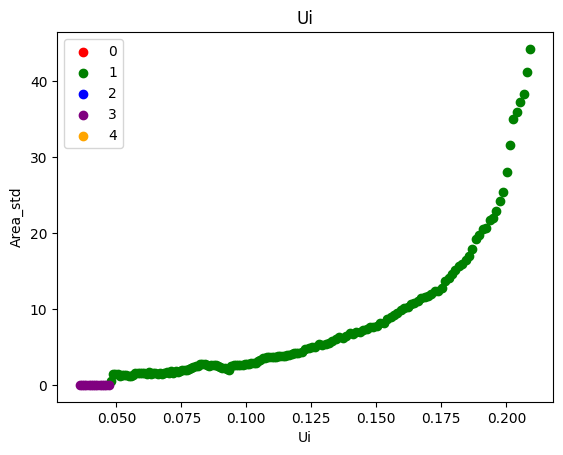

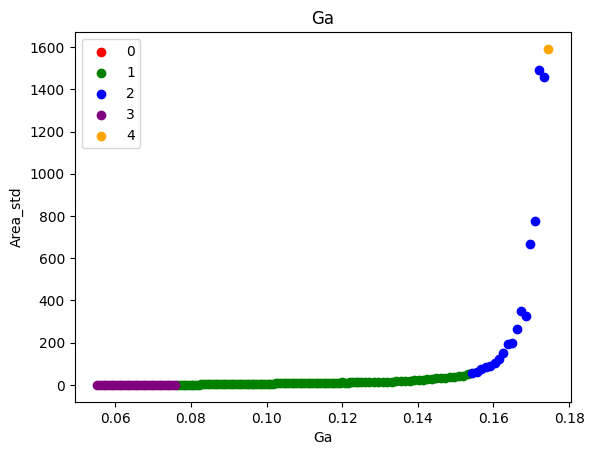

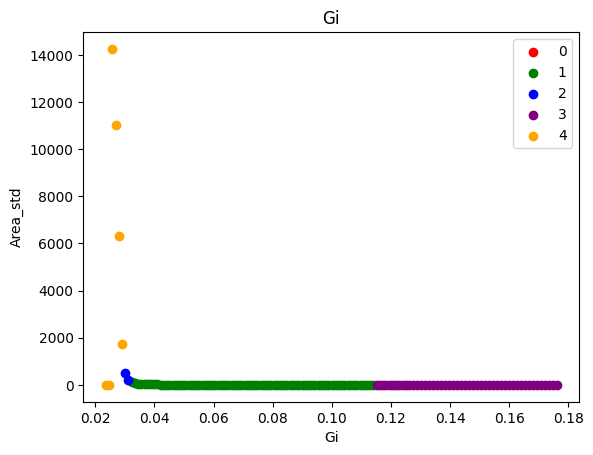

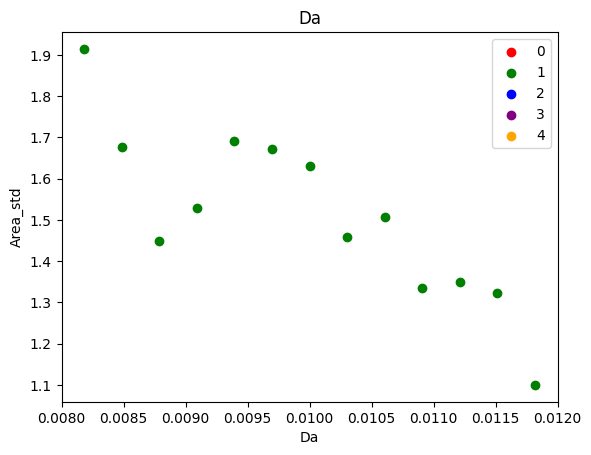

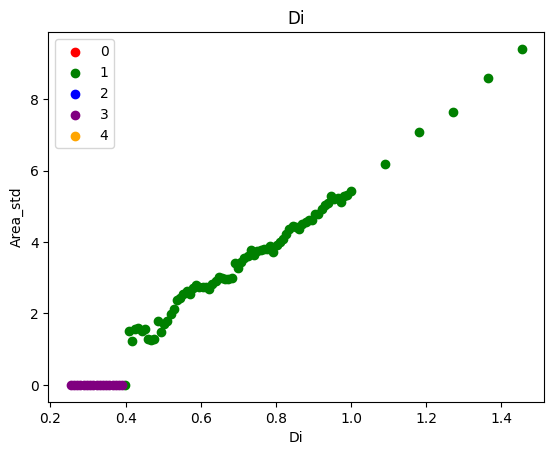

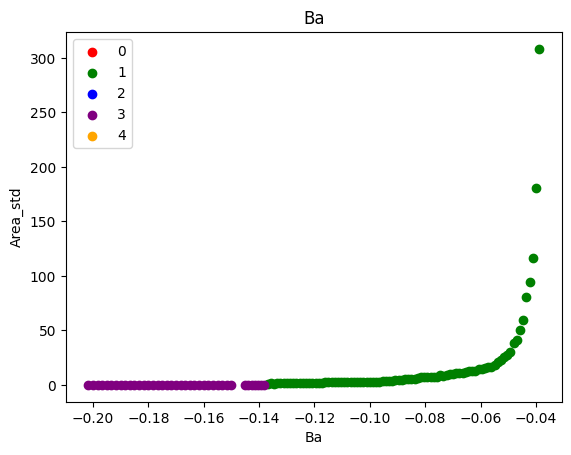

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "Area_std"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()

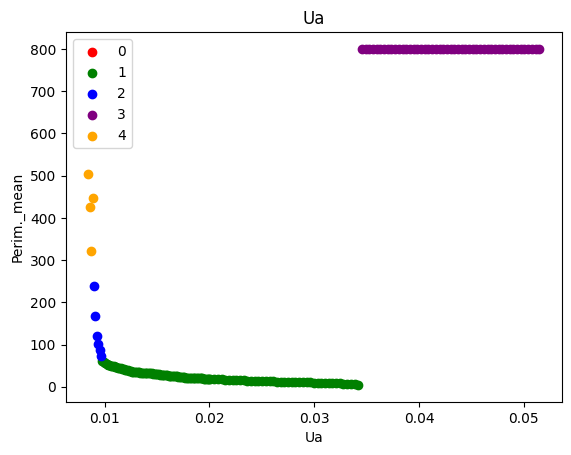

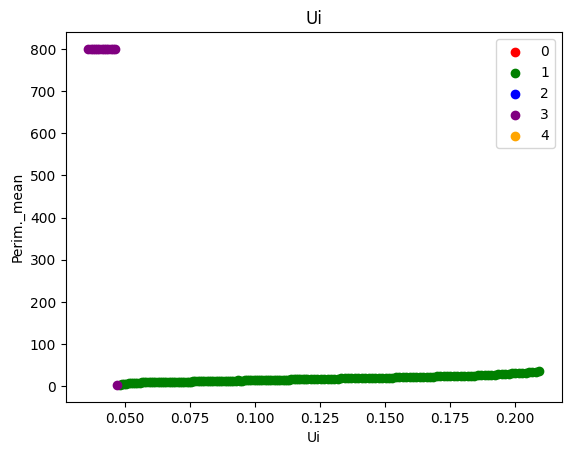

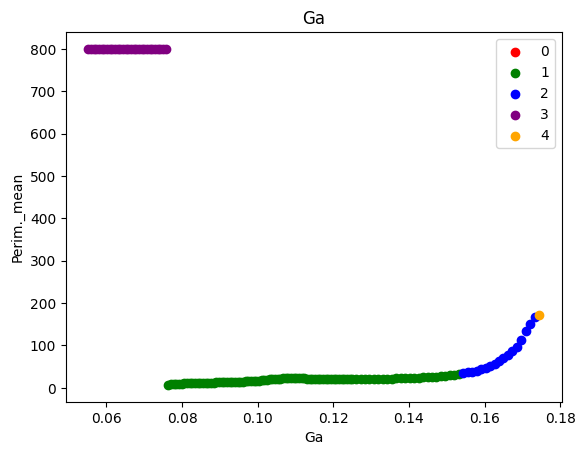

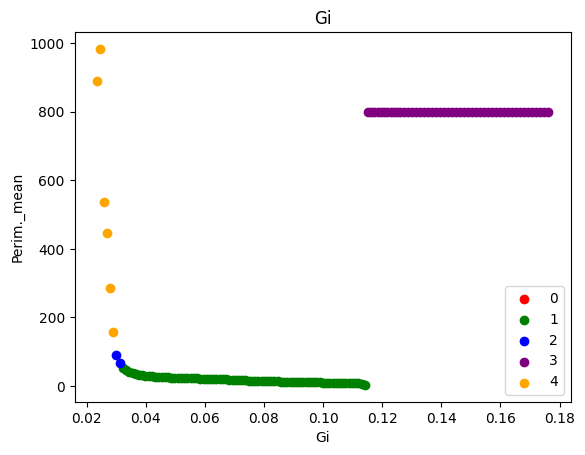

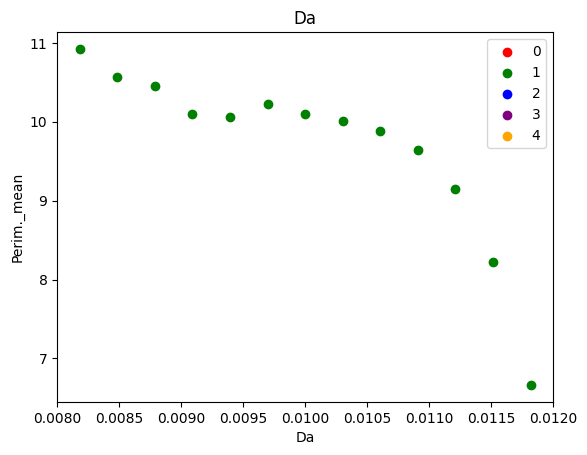

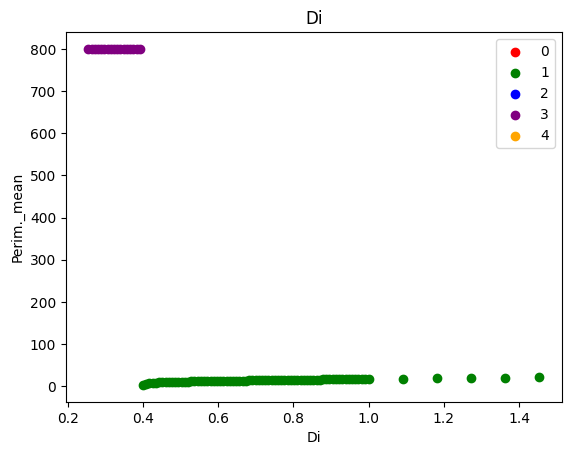

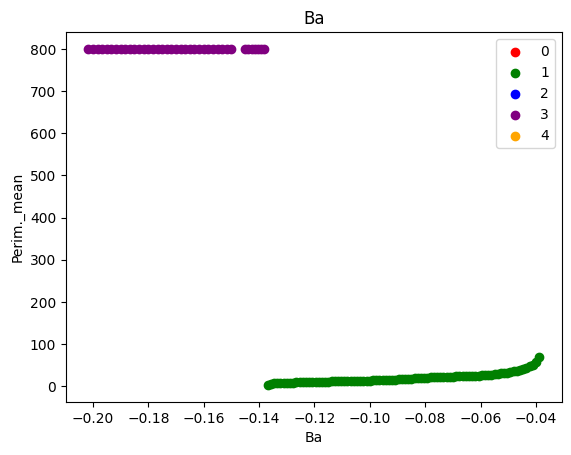

In [ ]:
# plot some dependencies

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "Perim._mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()